In [ ]:
# Importamos pandas para la manipulación y análisis del dataset
import pandas as pd
# Importamos StandardScaler de scikit-learn para estandarizar las variables
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset desde el archivo CSV
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

# ==========================================
# 1. Variable Objetivo (Target)
# ==========================================
# Nos aseguramos de que no haya nulos rellenando con 0 (por precaución)
df['Churned'] = df['Churned'].fillna(0)
# Convertimos la columna al tipo de dato entero (0 o 1)
df['Churned'] = df['Churned'].astype(int)

# ==========================================
# 2. Variables Categóricas (Demografía y Fechas)
# ==========================================
# Definimos las columnas de demografía
cols_demografia = ['Gender', 'Country', 'City']
# Imputamos los valores nulos con la etiqueta 'Unknown'
df[cols_demografia] = df[cols_demografia].fillna('Unknown')

# Aplicamos One-Hot Encoding a 'Gender' y eliminamos la primera columna para evitar colinealidad
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Aplicamos Frequency Encoding a 'Country' y 'City'
for col in ['Country', 'City']:
    # Calculamos la frecuencia (porcentaje) de cada categoría en la columna
    frecuencia = df[col].value_counts(normalize=True)
    # Mapeamos esos valores numéricos de vuelta a la columna original
    df[col] = df[col].map(frecuencia)

# Obtenemos la moda (trimestre más frecuente) de la columna de registro
moda_quarter = df['Signup_Quarter'].mode()[0]
# Imputamos los valores nulos con dicha moda
df['Signup_Quarter'] = df['Signup_Quarter'].fillna(moda_quarter)

# Definimos el diccionario para el mapeo ordinal de los trimestres
mapeo_quarter = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
# Aplicamos el mapeo para convertir los textos a números enteros
df['Signup_Quarter'] = df['Signup_Quarter'].map(mapeo_quarter)

# ==========================================
# 3. Variables Numéricas Discretas (Conteos e Interacciones)
# ==========================================
# Definimos las columnas donde la ausencia de dato significa inactividad (0)
cols_cero = ['Customer_Service_Calls', 'Product_Reviews_Written', 'Wishlist_Items', 'Returns_Rate', 'Discount_Usage_Rate']
# Imputamos los valores nulos de estas columnas con 0
df[cols_cero] = df[cols_cero].fillna(0)

# Definimos las columnas discretas básicas del comportamiento del cliente
cols_mediana_disc = ['Age', 'Login_Frequency', 'Total_Purchases', 'Days_Since_Last_Purchase', 'Payment_Method_Diversity']
# Imputamos los nulos calculando la mediana de cada una de estas columnas
df[cols_mediana_disc] = df[cols_mediana_disc].fillna(df[cols_mediana_disc].median())

# ==========================================
# 4. Variables Numéricas Continuas (Financieras y Navegación)
# ==========================================
# Definimos las variables continuas propensas a tener outliers
cols_continuas = ['Membership_Years', 'Session_Duration_Avg', 'Pages_Per_Session', 'Mobile_App_Usage',
                  'Average_Order_Value', 'Cart_Abandonment_Rate', 'Email_Open_Rate', 'Lifetime_Value', 'Credit_Balance']
# Rellenamos los valores nulos utilizando la mediana de cada columna
df[cols_continuas] = df[cols_continuas].fillna(df[cols_continuas].median())

# Calculamos el porcentaje total de valores nulos en el Score de redes sociales
porcentaje_nulos_social = df['Social_Media_Engagement_Score'].isnull().mean()
# Evaluamos si los nulos superan el 50% (0.5)
if porcentaje_nulos_social > 0.5:
    # Si supera el 50%, eliminamos la columna por completo
    df = df.drop(columns=['Social_Media_Engagement_Score'])
else:
    # Si es menor al 50%, calculamos la mediana y rellenamos los nulos con ella
    mediana_social = df['Social_Media_Engagement_Score'].median()
    df['Social_Media_Engagement_Score'] = df['Social_Media_Engagement_Score'].fillna(mediana_social)

# ==========================================
# 5. Transformación Final
# ==========================================
# Instanciamos el modelo para escalar los datos (media 0 y varianza 1)
scaler = StandardScaler()

# Separamos el nombre de todas las columnas, excepto nuestra variable objetivo 'Churned'
# (Notarás que a este punto TODAS las variables predictoras ya son numéricas)
cols_a_escalar = df.columns.drop('Churned')

# Ajustamos y transformamos las variables para estandarizarlas
df[cols_a_escalar] = scaler.fit_transform(df[cols_a_escalar])

# Mostramos las primeras 5 filas para comprobar que todo quedó perfecto
print(df.head())

        Age   Country      City  Membership_Years  Login_Frequency  \
0  0.449670 -0.907153 -0.915545         -0.040799         0.304118   
1 -0.157149 -0.316245 -0.258846         -0.672148         0.432150   
2  0.623047 -0.569827 -0.590131         -0.040799        -0.208008   
3  1.576619  1.336822  1.335513         -0.186495        -0.208008   
4 -0.243837 -0.991233 -0.999414          0.056331         2.224591   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0             -0.019266          -0.741695              -0.397970   
1              1.438275           0.431898              -1.190229   
2             -0.266953          -1.942582               0.848763   
3              1.028639           1.660078              -0.944567   
4              2.267073          -0.086666              -2.332555   

   Wishlist_Items  Total_Purchases  ...  Product_Reviews_Written  \
0       -0.291530        -0.585925  ...                 0.570281   
1       -0.902371         0.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Definimos el nombre que tendrá nuestro nuevo archivo ya limpio y procesado
nombre_archivo_limpio = 'ecommerce_customer_churn_dataset_limpio.csv'

# Exportamos nuestro DataFrame (df) al nuevo archivo CSV
# El parámetro index=False evita que se guarde la numeración de las filas como una columna nueva
df.to_csv(nombre_archivo_limpio, index=False)

# Imprimimos un mensaje en pantalla para confirmar que el proceso terminó
print("¡Los datos limpios se han guardado con éxito en:", nombre_archivo_limpio, "!")

¡Los datos limpios se han guardado con éxito en: ecommerce_customer_churn_dataset_limpio.csv !


In [ ]:
# Importamos la librería pandas, que es la herramienta principal para análisis de datos en Python
import pandas as pd

# (Opcional) Si aún no has subido el archivo al entorno de Colab, puedes descomentar
# las siguientes dos líneas para abrir el cuadro de diálogo y subirlo desde tu computadora:
# from google.colab import files
# subida = files.upload()

# Definimos el nombre exacto del archivo que vamos a leer
nombre_archivo = 'ecommerce_customer_churn_dataset_limpio.csv'

# Cargamos el archivo CSV en una estructura de tabla llamada DataFrame (df)
df = pd.read_csv(nombre_archivo)

# Mostramos las primeras 5 filas del DataFrame para confirmar que todo cargó correctamente
df.head()

,Age,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Gender_Male,Gender_Other
0,0.449670,-0.907153,-0.915545,-0.040799,0.304118,-0.019266,-0.741695,-0.397970,-0.291530,-0.585925,...,0.570281,-0.665654,0.168429,-1.231912,-0.537119,0.276395,0,-1.344075,1.043046,-0.138195
1,-0.157149,-0.316245,-0.258846,-0.672148,0.432150,1.438275,0.431898,-1.190229,-0.902371,0.910390,...,0.146727,-0.080417,0.448109,0.612019,-0.411309,0.925225,0,1.342606,1.043046,-0.138195
2,0.623047,-0.569827,-0.590131,-0.040799,-0.208008,-0.266953,-1.942582,0.848763,-0.902371,-0.571674,...,-0.700379,-0.080417,-1.174035,-0.309946,-0.166302,0.310134,0,1.342606,-0.958731,-0.138195
3,1.576619,1.336822,1.335513,-0.186495,-0.208008,1.028639,1.660078,-0.944567,1.540994,0.269112,...,0.993834,2.938988,1.309524,0.612019,0.992343,0.618977,0,-1.344075,-0.958731,-0.138195
4,-0.243837,-0.991233,-0.999414,0.056331,2.224591,2.267073,-0.086666,-2.332555,1.540994,2.762969,...,3.535155,2.788795,3.479841,1.533984,1.764322,2.937463,0,1.342606,1.043046,-0.138195


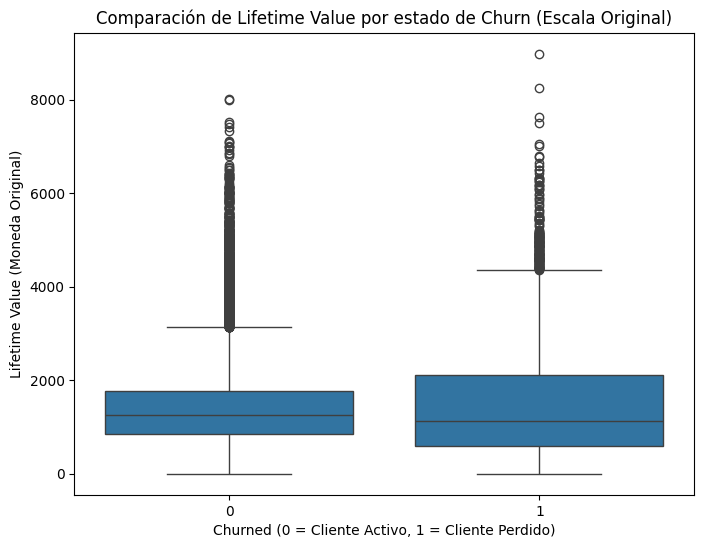

In [ ]:
# Importamos las librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargamos el archivo ORIGINAL (antes del escalado) solo para este gráfico
# Esto nos permite ver el Lifetime Value en su moneda real
nombre_archivo_original = 'ecommerce_customer_churn_dataset.csv'
df_original = pd.read_csv(nombre_archivo_original)

# Aplicamos la misma regla de limpieza que usamos antes para que los datos sean coherentes
# Rellenamos los nulos en 'Lifetime_Value' con la mediana y aseguramos que 'Churned' sea entero
mediana_ltv = df_original['Lifetime_Value'].median()
df_original['Lifetime_Value'] = df_original['Lifetime_Value'].fillna(mediana_ltv)
df_original['Churned'] = df_original['Churned'].fillna(0).astype(int)

# Creamos la figura y le asignamos un tamaño de 8x6 pulgadas
plt.figure(figsize=(8, 6))

# Creamos el gráfico de cajas usando los datos ORIGINALES
sns.boxplot(x='Churned', y='Lifetime_Value', data=df_original)

# Le ponemos un título claro a nuestro gráfico indicando que es la escala original
plt.title('Comparación de Lifetime Value por estado de Churn (Escala Original)')

# Nombramos el eje horizontal (X)
plt.xlabel('Churned (0 = Cliente Activo, 1 = Cliente Perdido)')

# Nombramos el eje vertical (Y) aclarando que es la moneda original
plt.ylabel('Lifetime Value (Moneda Original)')

# Mostramos el gráfico en pantalla
plt.show()

/tmp/ipython-input-2202/1802294497.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_3_valores_reales.values, y=top_3_valores_reales.index, palette='coolwarm')


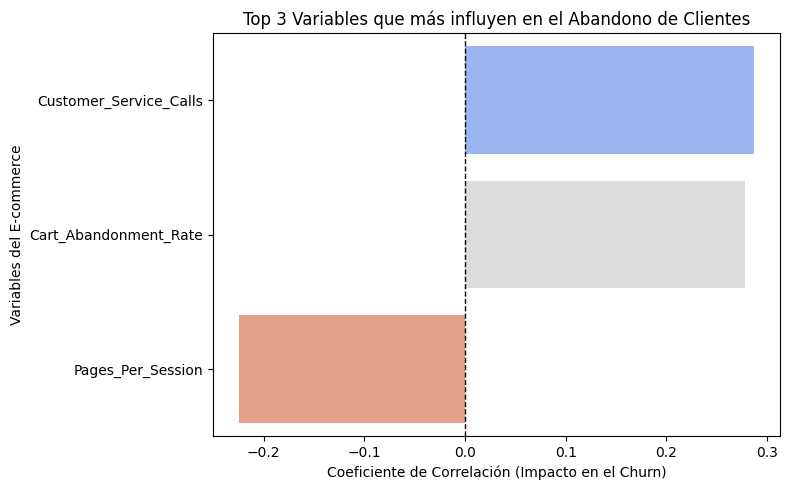

In [ ]:
# Importamos las herramientas necesarias para cálculo y gráficos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos nuestro archivo limpio
nombre_archivo = 'ecommerce_customer_churn_dataset_limpio.csv'
df = pd.read_csv(nombre_archivo)

# Calculamos las correlaciones enfocándonos solo en la columna 'Churned' y la quitamos de la lista
correlaciones = df.corr()['Churned'].drop('Churned')

# Buscamos el Top 3 de variables que más impactan (sin importar si es positivo o negativo)
top_3_influencia = correlaciones.abs().sort_values(ascending=False).head(3)

# Rescatamos los valores reales (con su signo + o -) solo para esas 3 variables top
top_3_valores_reales = correlaciones[top_3_influencia.index]

# ==========================================
# CREACIÓN DEL GRÁFICO
# ==========================================

# Preparamos un "lienzo" para nuestro gráfico de 8x5 pulgadas
plt.figure(figsize=(8, 5))

# Creamos un gráfico de barras horizontales (barplot)
# 'coolwarm' pinta los valores negativos en azul (bueno) y los positivos en rojo (malo)
sns.barplot(x=top_3_valores_reales.values, y=top_3_valores_reales.index, palette='coolwarm')

# Le ponemos título y nombramos los ejes para que se entienda sin contexto
plt.title('Top 3 Variables que más influyen en el Abandono de Clientes')
plt.xlabel('Coeficiente de Correlación (Impacto en el Churn)')
plt.ylabel('Variables del E-commerce')

# Dibujamos una línea punteada justo en el cero (0) para marcar la mitad exacta
plt.axvline(0, color='black', linewidth=1, linestyle='--')

# Ajustamos los márgenes automáticamente para que no se corte ningún texto
plt.tight_layout()

# Mostramos nuestro gráfico en pantalla
plt.show()